In [ ]:
# Import libraries
# standard
import pandas as pd
import numpy as np

# ploting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
from IPython.display import Image
from mlxtend.plotting import scatterplotmatrix, heatmap
import seaborn as sns

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.model_selection import TimeSeriesSplit

In [ ]:
# Load the dataset
df = pd.read_csv('https://zenodo.org/records/14712845/files/CA_Weather_Fire_Dataset_1984-2025.csv?download=1')

In [ ]:
# Data Cleanup
df.isna().sum()

,0
DATE,0
PRECIPITATION,1
MAX_TEMP,1
MIN_TEMP,1
AVG_WIND_SPEED,12
FIRE_START_DAY,0
YEAR,0
TEMP_RANGE,1
WIND_TEMP_RATIO,12
MONTH,0


In [ ]:
df.head()

,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
0,1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700,1
1,1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145,2
2,1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220,3
3,1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090,4
4,1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100,5


numpy.ndarray

In [ ]:
# Set the data frame index to be time if it is not so.
df.set_index('DATE', inplace=True)

# Sort time frame by time: it is important to sort dataframe by time before the time series split
df.sort_index(inplace=True)

# prepare features dataframe (X) and target (y) as data series
X = df #df.drop(labels=['FIRE_START_DAY'], axis=1)
y = df['FIRE_START_DAY']


In [ ]:
n_samples = len(X)

# Calculate split indices
train_end = int(0.6 * n_samples)  # 60% for training
val_end = train_end + int(0.2 * n_samples)  # 20% for validation

# Split the data
X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

In [ ]:
X_train.head()

,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
DATE,,,,,,,,,,,,,
1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700,1
1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145,2
1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220,3
1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090,4
1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100,5


In [ ]:
numeric_features = ['PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPEED', 'TEMP_RANGE', 'WIND_TEMP_RATIO', 'LAGGED_PRECIPITATION', 'LAGGED_AVG_WIND_SPEED', 'FIRE_START_DAY']
X_train_numeric = df[numeric_features]


In [ ]:
X_train_numeric.dtypes


,0
PRECIPITATION,float64
MAX_TEMP,float64
MIN_TEMP,float64
AVG_WIND_SPEED,float64
TEMP_RANGE,float64
FIRE_START_DAY,bool


In [ ]:
# Set global font size
plt.rcParams['axes.labelsize'] = 16  # Axis labels
plt.rcParams['xtick.labelsize'] = 16  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 16  # Y-axis tick labels
plt.rcParams['axes.titlesize'] = 16  # Plot title

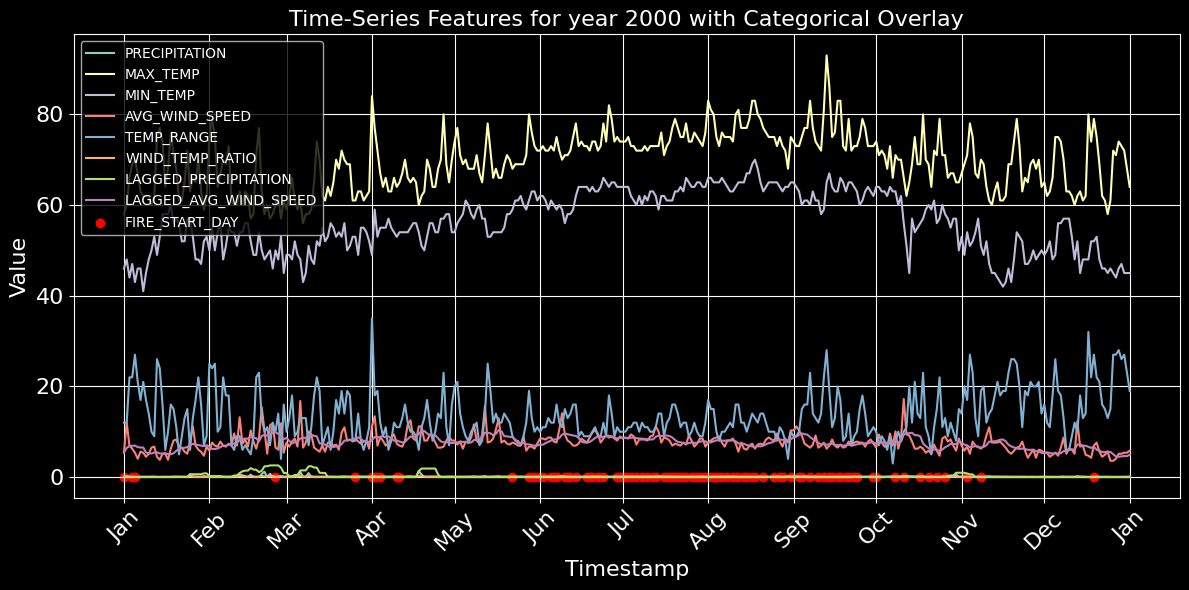

In [ ]:
# Select a specific year (e.g., 2000)
year_to_plot = 2000
X_train_numeric = X_train[numeric_features].loc[f'{year_to_plot}-01-01':f'{year_to_plot}-12-31']

# Plot numerical features
numerical_columns = X_train_numeric.select_dtypes(include='number').columns  # Get numerical columns
categorical_column = 'FIRE_START_DAY'  # Categorical column

# Set background color to dark
plt.style.use('dark_background')

# Create subplots
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each numerical feature
for col in numerical_columns:
    ax.plot(X_train_numeric.index, X_train_numeric[col], label=col)

# Overlay categorical column as dots
categorical_data = X_train_numeric[X_train_numeric[categorical_column] == True]  # Filter rows where categorical is True
ax.scatter(categorical_data.index, [0] * len(categorical_data), color='red', label=categorical_column, marker='o')

# Format x-axis to show monthly ticks
ax.xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks to the first day of each month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format ticks as "Month Year"

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add labels, title, and legend
ax.set_xlabel('Timestamp')
ax.set_ylabel('Value')
ax.set_title(f'Time-Series Features for year {year_to_plot} with Categorical Overlay')
ax.legend(loc='upper left')

# Add grid
ax.grid(True)

plt.tight_layout()  # Adjust layout to prevent label overlap

# Save the plot as a PNG file with a transparent background
plt.savefig('timeseries.png', transparent=False, bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
X_train_numeric.head()

,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,TEMP_RANGE,FIRE_START_DAY
DATE,,,,,,
2000-01-01,0.0,58.0,46.0,5.37,12.0,True
2000-01-02,0.0,60.0,48.0,12.08,12.0,False
2000-01-03,0.0,66.0,44.0,6.93,22.0,False
2000-01-04,0.0,69.0,47.0,6.26,22.0,True
2000-01-05,0.0,70.0,43.0,5.37,27.0,True


(9, 9)


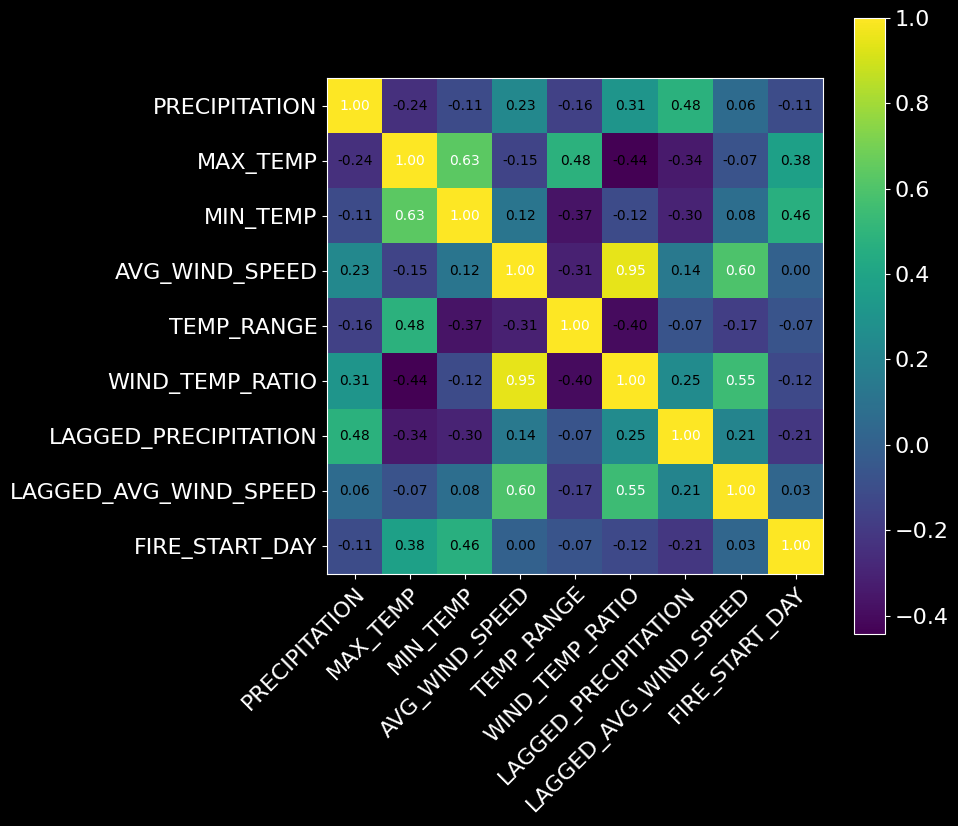

In [ ]:
#X_train_corr = X_train_numeric.drop('FIRE_START_DAY', inplace=True)
X_train_numeric = X_train[numeric_features]
cm = X_train_numeric.corr().values
print(cm.shape)
hm = heatmap(
    cm,
    row_names=X_train_numeric.columns,
    column_names=X_train_numeric.columns,
    figsize=(8, 8)
)
# Set background color to dark
plt.style.use('dark_background')
# Save the plot as a PNG file with a transparent background
plt.savefig('heatmap.png', transparent=False, bbox_inches='tight', dpi=300)

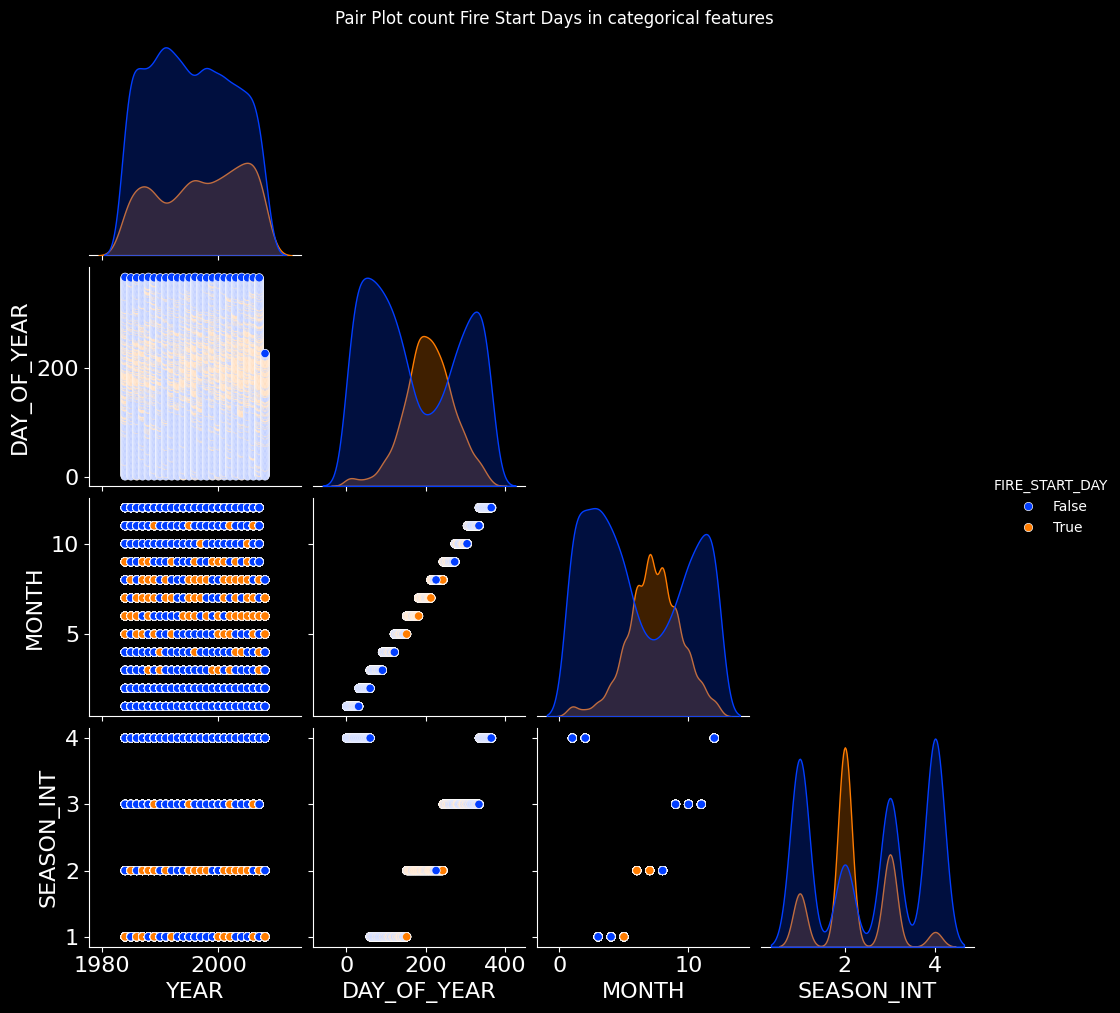

In [ ]:
# Convert the 'SEASON' column to integers
# Mapping dictionary
season_to_int = {
    'Spring': 1,
    'Summer': 2,
    'Fall': 3,
    'Winter': 4
}

# Convert the 'season' column to integers
X_train = X_train.copy()
X_train['SEASON_INT'] = X_train['SEASON'].map(season_to_int)
cat_features = ['YEAR', 'DAY_OF_YEAR', 'MONTH', 'SEASON_INT']
# Plot categorical features pairplot
# Set background color to dark
plt.style.use('dark_background')
pairplot = sns.pairplot(pd.concat([X_train[cat_features], y_train], axis=1), hue="FIRE_START_DAY", corner=True, palette='bright')
pairplot.fig.suptitle(f"Pair Plot count Fire Start Days in categorical features", y=1.01)
pairplot.savefig('pairplot.png', transparent=False, bbox_inches='tight', dpi=300)

In [ ]:
X_train.SEASON.unique()

array(['Winter', 'Spring', 'Summer', 'Fall'], dtype=object)

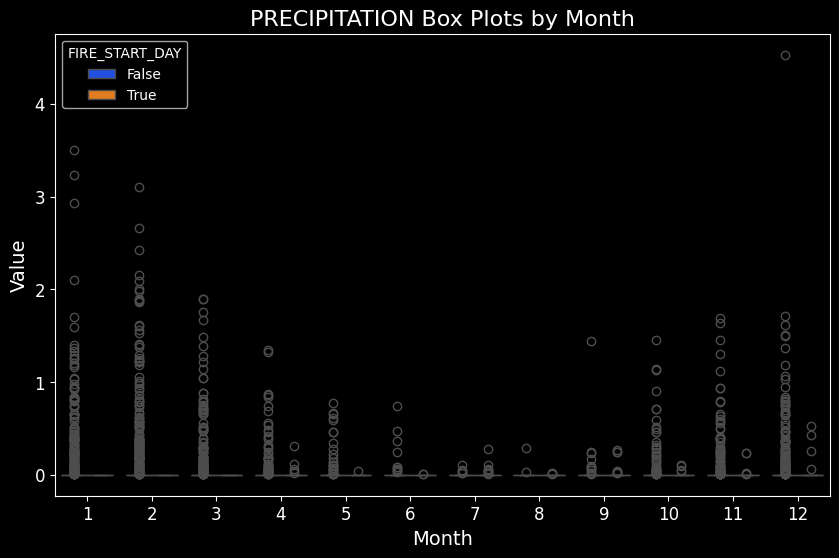

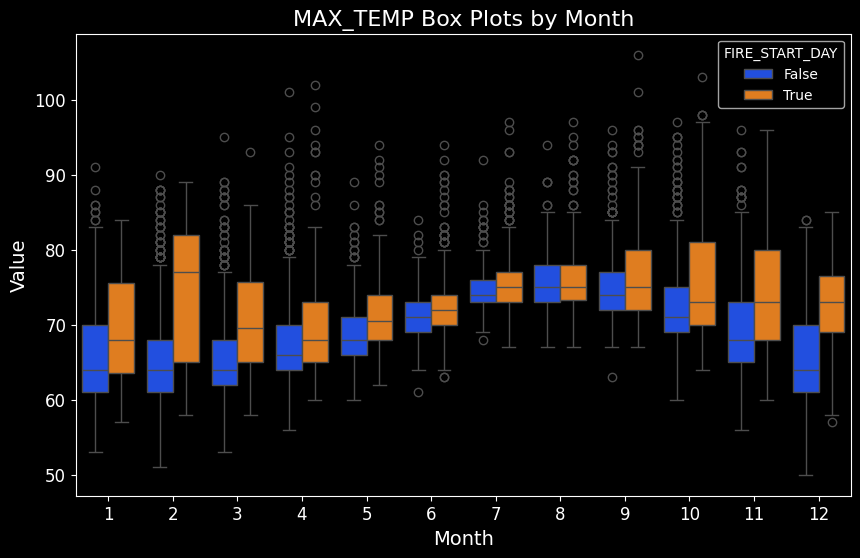

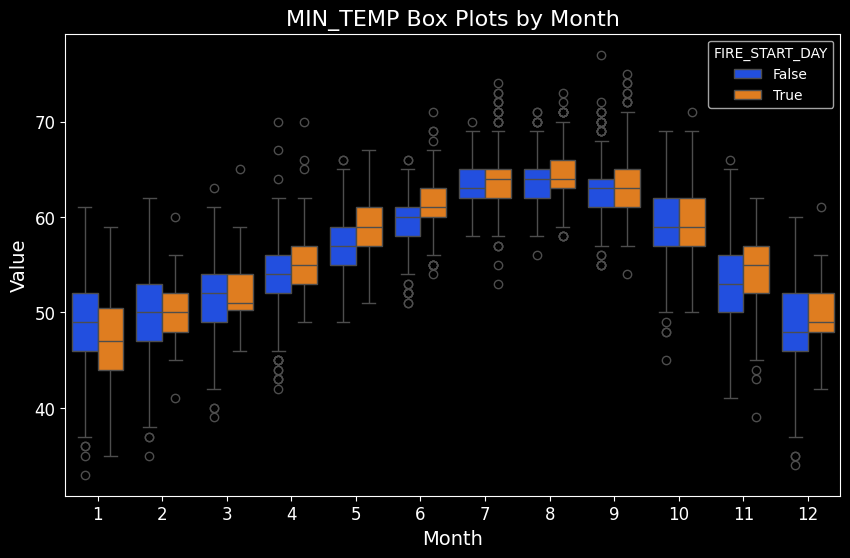

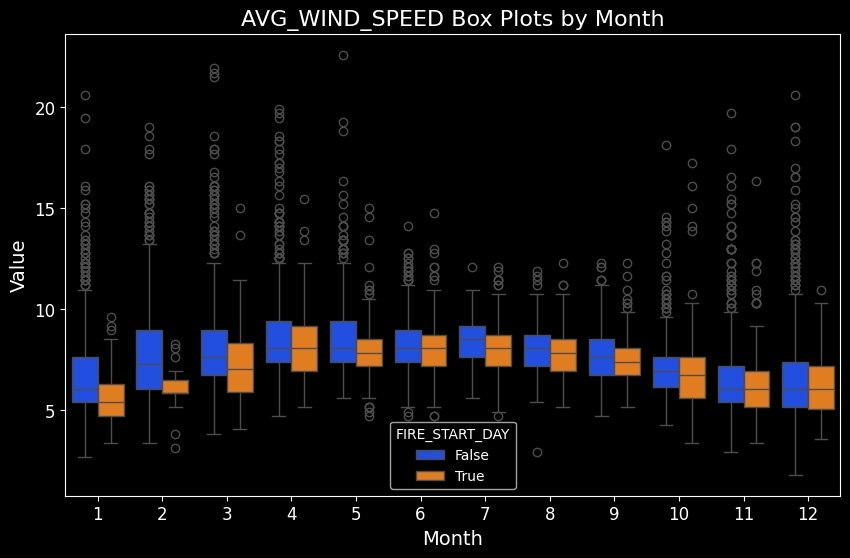

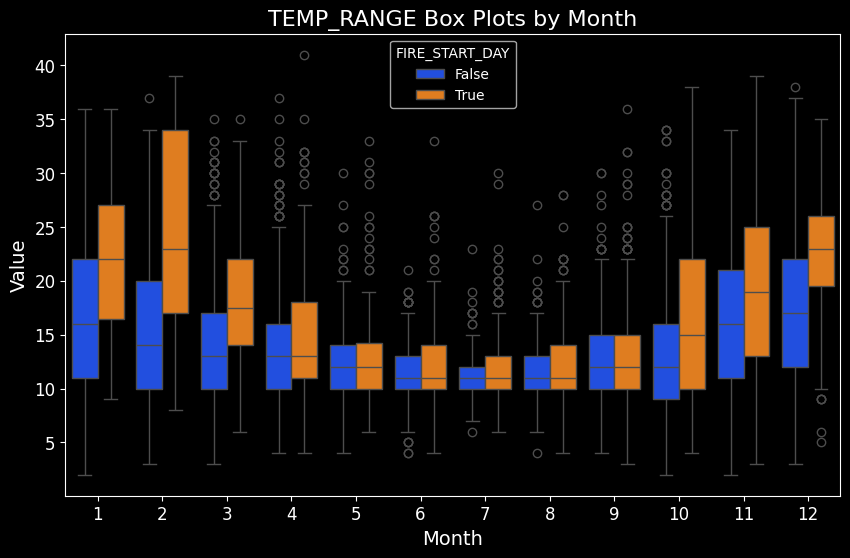

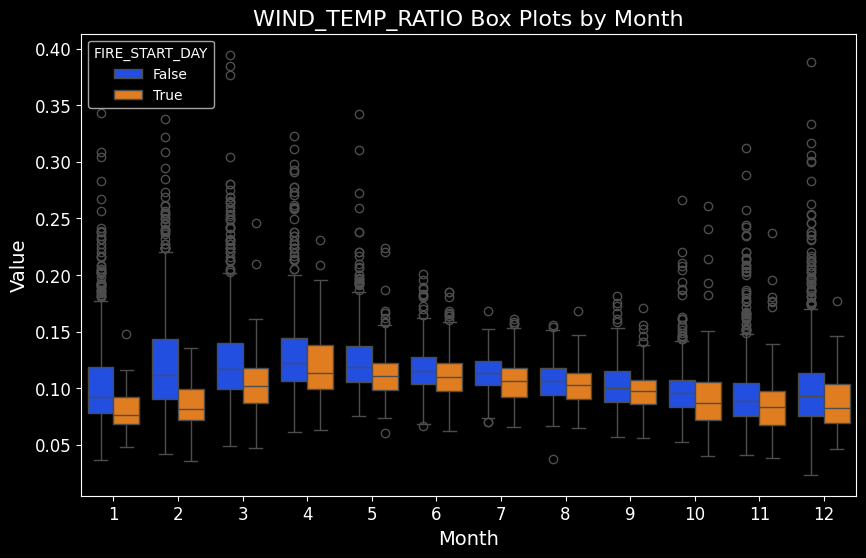

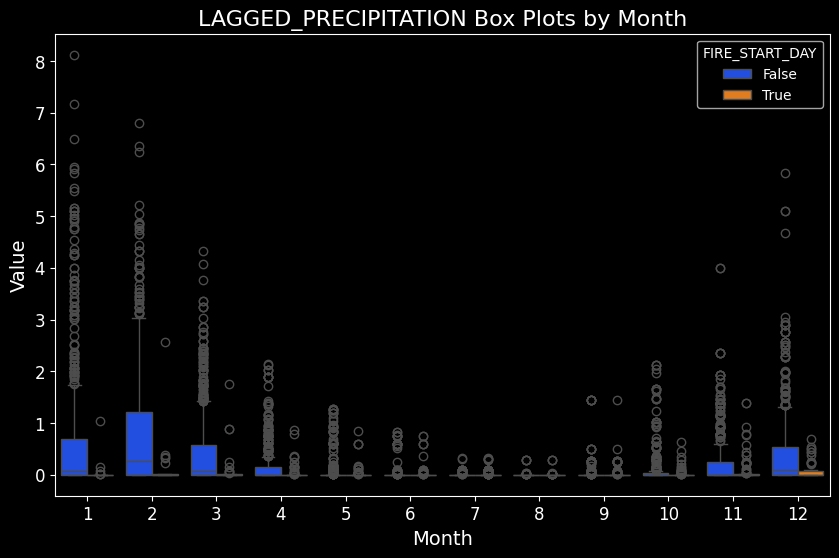

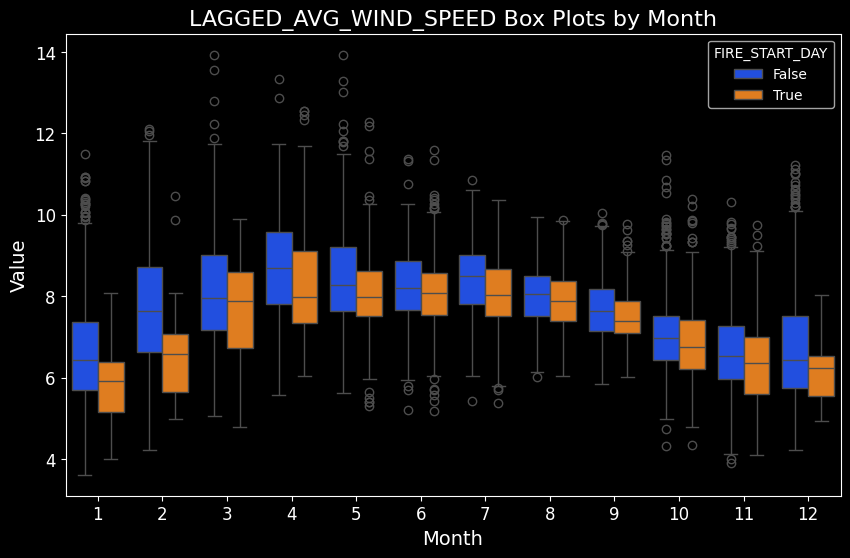

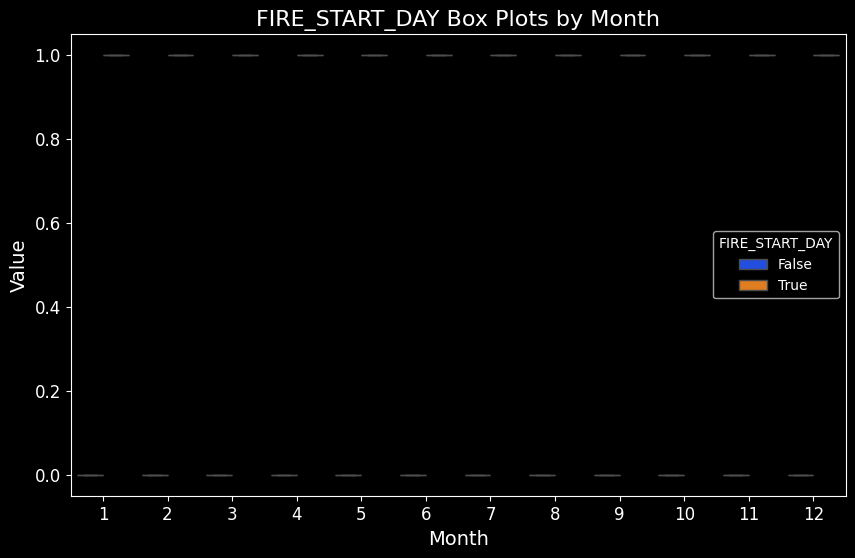

In [ ]:
# Create box plots for each numerical feature by month
#numeric_features = ['PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPEED', 'TEMP_RANGE', 'FIRE_START_DAY']
for nf in numeric_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='MONTH', y=nf, hue='FIRE_START_DAY', data=X_train, palette='bright')

    # Customize the plot
    plt.title(nf + ' Box Plots by Month', fontsize=16)
    plt.xlabel('Month', fontsize=14)
    plt.ylabel('Value', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # Show the plot
    plt.show()